## Validation of PVade against DuraMAT experimental campaign ##

In [1]:
import pandas as pd
import numpy as np
import yaml
import pickle
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
pwd

'/kfs2/projects/pvopt/aps_dfd_2024/PVade/postprocessing'

In [3]:
# copying from https://github.com/brookeslawski/scripts/blob/main/pvade-pproc-aps2024.ipynb
parentdir = '/scratch/bstanisl/pvade/turb_inflow/'
casepath = 'y20m_turbinflow_duramat_validation/'

exp_data_fn = 'DuraMAT_tilt40deg_turbulent_inflow_10min_timeseries.csv'

tilts = [40.0]
# panel_span = 10.0
# panel_chord = 4.1

### Step 1: read in csv data (lift and drag, acceleration at NE corner of panel) ###

In [4]:
# read in lift and drag
output_dir=parentdir+'output/'+casepath
tmp = pd.read_csv(output_dir+'solution/lift_and_drag.csv')
tmp.rename(columns={'#Time': 'Time'}, inplace=True)
tmp = tmp.set_index('Time')
loadsdata = tmp

# read in accelerations
tmp2 = pd.read_csv(output_dir+'solution/accel_pos.csv')
loadsdata['accel-x'] = tmp2['#x-pos'].values
loadsdata['accel-y'] = tmp2['y-pos'].values
loadsdata['accel-z'] = tmp2['z-pos'].values
loadsdata['accel-magnitude'] = loadsdata['accel-x']**2 + loadsdata['accel-y']**2 + loadsdata['accel-z']**2

# clean up
del tmp
del tmp2

loadsdata

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude
Time,,,,,,,,,,
0.006,80095.786570,25.356473,94328.264350,43.713611,0.013839,51.481223,0.000000,0.000000,0.000000,0.000000e+00
0.012,15358.255090,16.459162,16302.197970,8.382024,0.008983,8.897196,0.003672,-0.000060,0.004102,3.031568e-05
0.018,5395.130808,10.003737,4495.901407,2.944483,0.005460,2.453713,0.010679,-0.000048,0.011900,2.556458e-04
0.024,10068.180040,2.107822,11408.066990,5.494877,0.001150,6.226143,0.006625,0.000050,0.007275,9.683186e-05
0.030,8709.975539,-2.303399,9799.812632,4.753614,-0.001257,5.348411,-0.010980,-0.000066,-0.012541,2.778219e-04
...,...,...,...,...,...,...,...,...,...,...
29.976,2749.613209,-6.071575,3032.472308,1.500647,-0.003314,1.655022,-0.000248,-0.000011,-0.000319,1.632866e-07
29.982,2797.885123,-6.294778,3087.542732,1.526992,-0.003435,1.685078,-0.000251,-0.000011,-0.000322,1.667396e-07
29.988,2825.244245,-6.449536,3116.306275,1.541924,-0.003520,1.700776,-0.000285,-0.000011,-0.000359,2.103726e-07


### Step 2: Read in post-processed velocity data from PVade sim ###

In [12]:
# read input parameters
with open(output_dir+'input_params.yaml', 'r') as file:
    params = yaml.safe_load(file)

print('tracker_angle = {} m/s'.format(params['pv_array']['tracker_angle']))
dt_sim = params['solver']['dt']
dt_xdmf = params['solver']['save_xdmf_interval']
panel_span = params['pv_array']['panel_span']
panel_chord = params['pv_array']['panel_chord']
tf = params['solver']['t_final']

tracker_angle = 40.0 m/s


In [6]:
# read velocity data
readdata = {}
coords = {}
    
for j, tilt in enumerate(tilts):
    readdata[tilt] = {}
    coords[tilt] = {}

    pkl_fname = f'duramatval_tracker_angle_{tilt}.pkl'
    pkl_path = parentdir+'interp_data/timeseries_data/'+pkl_fname

    print('reading from', pkl_path)

    try:
        with open(pkl_path, 'rb') as f:
            # try:
            readrawdata = pickle.load(f)
                
            # print(rawdata[winddir][tilt][case].keys())
            readdata[tilt]['u'] = readrawdata['u']
            readdata[tilt]['v'] = readrawdata['v']
            readdata[tilt]['w'] = readrawdata['w']
            print('vel data nt, nx, ny, nz = ', np.shape(readdata[tilt]['u']))
    except Exception as e:
        print(f"Error loading pickle file: {e}")

# i think coords are only different for each tilt angle
if 'X' in readrawdata.keys():
    tmpX = readrawdata['X']
    print('coord nx, ny, nz = ', np.shape(tmpX))
    del tmpX

    coords[tilt]['X'] = readrawdata['X']
    coords[tilt]['Y'] = readrawdata['Y']
    coords[tilt]['Z'] = readrawdata['Z']
                        
del readrawdata

ndim = len(np.shape(readdata[tilt]['u']))

reading from /scratch/bstanisl/pvade/turb_inflow/interp_data/timeseries_data/duramatval_tracker_angle_40.0.pkl
vel data nt, nx, ny, nz =  (2501, 150, 50, 50)
coord nx, ny, nz =  (150, 50, 50)


In [30]:
# create dataframe from velocity data
nt = np.shape(readdata[tilt]['u'])[0]
time_xdmf = np.linspace(0, tf, nt)

xi = coords[tilt]['X'][:,0,0]
yi = coords[tilt]['Y'][0,:,0]
zi = coords[tilt]['Z'][0,0,:]

# velocity signal at sonic location
[xloc, yloc, zloc] = [-12.36, 0.0, 2.23]
# [xloc, yloc, zloc] = [-12.36, 4.5, 2.23]
i = int(np.argmin(np.abs(xi - xloc)))
j = int(np.argmin(np.abs(yi - yloc)))
k = int(np.argmin(np.abs(zi - zloc)))
print(f'sonic loc indices = {i, j, k}')

vel_data = pd.DataFrame(index=time_xdmf)
for comp in ['u', 'v', 'w']:
    vel_data[comp+' (m/s) at inlet'] = readdata[tilt][comp][:,0,j,k]
for comp in ['u', 'v', 'w']:
    vel_data[comp+' (m/s) at sonic'] = readdata[tilt][comp][:,i,j,k]
vel_data

sonic loc indices = (19, 24, 29)


,u (m/s) at inlet,v (m/s) at inlet,w (m/s) at inlet,u (m/s) at sonic,v (m/s) at sonic,w (m/s) at sonic
0.000,NaN,NaN,NaN,NaN,NaN,NaN
0.012,NaN,NaN,NaN,NaN,NaN,NaN
0.024,NaN,NaN,NaN,NaN,NaN,NaN
0.036,NaN,NaN,NaN,NaN,NaN,NaN
0.048,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
29.952,10.458623,2.718298,0.612247,11.765216,1.128108,0.417574
29.964,10.165004,2.372044,0.735119,12.197557,1.092484,1.380910
29.976,10.355655,2.146924,0.562671,12.893835,1.003458,1.928866
29.988,10.313957,2.004963,0.433945,13.276855,0.641553,1.119396


In [31]:
# merge sim data
sim_data = pd.merge(loadsdata, vel_data, left_index=True, right_index=True, how='inner')
sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude,u (m/s) at inlet,v (m/s) at inlet,w (m/s) at inlet,u (m/s) at sonic,v (m/s) at sonic,w (m/s) at sonic
0.012,15358.255090,16.459162,16302.197970,8.382024,0.008983,8.897196,0.003672,-0.000060,0.004102,3.031568e-05,NaN,NaN,NaN,NaN,NaN,NaN
0.024,10068.180040,2.107822,11408.066990,5.494877,0.001150,6.226143,0.006625,0.000050,0.007275,9.683186e-05,NaN,NaN,NaN,NaN,NaN,NaN
0.048,3621.592487,0.014917,4056.564604,1.976544,0.000008,2.213938,0.010479,0.000115,0.011792,2.488648e-04,NaN,NaN,NaN,NaN,NaN,NaN
0.060,6551.188208,-2.773338,7677.709417,3.575420,-0.001514,4.190238,-0.009872,-0.000130,-0.010940,2.171593e-04,NaN,NaN,NaN,NaN,NaN,NaN
0.084,10115.382190,-2.272474,12013.586170,5.520639,-0.001240,6.556615,-0.009108,-0.000054,-0.010269,1.884019e-04,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.940,2628.654073,-5.600960,2909.274066,1.434632,-0.003057,1.587785,-0.000317,-0.000012,-0.000397,2.586497e-07,10.811236,3.365272,0.333681,11.920018,0.912882,0.058753
29.952,2749.651912,-5.965080,3039.299693,1.500668,-0.003256,1.658748,-0.000251,-0.000012,-0.000325,1.684896e-07,10.458623,2.718298,0.612247,11.765216,1.128108,0.417574
29.976,2749.613209,-6.071575,3032.472308,1.500647,-0.003314,1.655022,-0.000248,-0.000011,-0.000319,1.632866e-07,10.355655,2.146924,0.562671,12.893835,1.003458,1.928866
29.988,2825.244245,-6.449536,3116.306275,1.541924,-0.003520,1.700776,-0.000285,-0.000011,-0.000359,2.103726e-07,10.313957,2.004963,0.433945,13.276855,0.641553,1.119396


### Step 3: read in measurement data from DuraMAT ###

In [10]:
# read in experimental data
def read_csv_data(raw_data):
    # read csv
    exp_data = raw_data
    
    # construct time index
    tmp = (exp_data.index[1]-exp_data.index[0])
    dt_sonic1 = round(tmp.total_seconds(), 3)
    tf_sonic1 = len(exp_data) * dt_sonic1 # final time [s]
    t_sonic1 = np.arange(0.0, tf_sonic1, dt_sonic1)

    exp_data['u (m/s)'] = -1.0*exp_data['u (m/s)'] # to make it positive from the west
    exp_data['Time'] = t_sonic1
    exp_data = exp_data.set_index('Time')

    return tf_sonic1, exp_data
    
raw_exp_data = pd.read_csv(exp_data_fn, index_col='Time')
raw_exp_data.index = pd.to_datetime(raw_exp_data.index)

tf_sonic1, exp_data = read_csv_data(raw_exp_data)
dt = exp_data.index[1]-exp_data.index[0]

# cut sonic data to time period simulated
exp_data = exp_data[exp_data.index <= loadsdata.index[-1]]

exp_data

,3D wind speed (m/s),Wind direction (deg),u (m/s),v (m/s),w (m/s),temp (degC),Drive tracker angle (deg),Drive torque north (kNm),Panel defl mid (mm),Drag force (kN),Lift force (kN),Drag force tracker angle (kN),Lift force tracker angle (kN)
Time,,,,,,,,,,,,,
0.00,9.568380,270.04733,9.541354,0.007880,0.718606,14.153721,40.542965,-2.530350,2.693880,1.400373,3.847494,3.992168,4.667137
0.02,9.567942,270.04828,9.540954,0.008039,0.718082,14.153996,40.541090,-2.579051,2.677513,1.427326,3.921546,4.068848,4.757097
0.04,9.567616,270.04276,9.540588,0.007120,0.718604,14.154172,40.541640,-2.544011,2.768883,1.407934,3.868266,4.013612,4.692427
0.06,9.568180,270.03586,9.541167,0.005969,0.718446,14.155300,40.545723,-2.507620,2.833717,1.387794,3.812933,3.956530,4.625022
0.08,9.568017,270.03380,9.541007,0.005632,0.718398,14.154648,40.539486,-2.425076,2.631208,1.342111,3.687421,3.825804,4.473195
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29.92,11.229149,261.20718,11.088928,-1.715236,-0.432913,14.274782,40.543350,-1.944552,2.135815,1.076175,2.956765,3.067970,3.586632
29.94,11.228396,261.21030,11.088281,-1.714519,-0.432846,14.277039,40.539375,-1.956167,2.210145,1.082603,2.974427,3.086046,3.608271
29.96,11.229111,261.20935,11.088963,-1.714808,-0.432761,14.275835,40.544342,-1.946597,2.414072,1.077306,2.959875,3.071259,3.590352


In [13]:
# calculate lift and drag force coefficients
sfc_area = panel_span * panel_chord
exp_data['Drag Coefficient'] = (exp_data['Drag force tracker angle (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)
exp_data['Lift Coefficient'] = (exp_data['Lift force tracker angle (kN)']*1000)/(0.5*1*exp_data['3D wind speed (m/s)']**2*sfc_area)

In [14]:
# interpolate to 50 Hz to match duramat loads signals
new_time_index = exp_data[exp_data.index>0.0].index
interp_sim_data = pd.DataFrame(index=new_time_index)
for col in loadsdata.columns:
    interpolator = interp1d(loadsdata.index, loadsdata[col].values, kind='linear')  # Use 'linear' or 'cubic' as needed
    interp_sim_data[col] = interpolator(new_time_index)

interp_sim_data

,fx_0,fy_0,fz_0,fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude
Time,,,,,,,,,,
0.02,6952.813885,7.371765,6799.956601,3.794614,0.004023,3.711190,0.009328,-0.000015,0.010358,2.027078e-04
0.04,-3612.071976,1.003233,-4649.960525,-1.971349,0.000548,-2.537793,-0.005903,-0.000096,-0.006841,2.217167e-04
0.06,6551.188208,-2.773338,7677.709417,3.575420,-0.001514,4.190238,-0.009872,-0.000130,-0.010940,2.171593e-04
0.08,9925.812304,-2.165652,11794.850210,5.417178,-0.001182,6.437236,-0.001258,-0.000053,-0.001547,7.282681e-05
0.10,3500.954128,-2.181478,4187.521554,1.910704,-0.001191,2.285410,0.006502,-0.000003,0.007139,1.035890e-04
...,...,...,...,...,...,...,...,...,...,...
29.92,2532.106151,-5.569994,2806.016115,1.381939,-0.003040,1.531430,-0.000252,-0.000011,-0.000323,1.699048e-07
29.94,2628.654073,-5.600960,2909.274066,1.434632,-0.003057,1.587785,-0.000317,-0.000012,-0.000397,2.586497e-07
29.96,2784.923558,-5.942468,3077.725183,1.519918,-0.003243,1.679720,-0.000293,-0.000012,-0.000371,2.244782e-07


In [15]:
# merge dataframes
alldata = {}

alldata['exp'] = exp_data.copy()
alldata['sim'] = interp_sim_data.copy()

# adjustments
for comp in ['fx','fy','fz']:
    alldata['sim'][comp+'_0'] = alldata['sim'][comp+'_0']/1000
    
alldata['sim'] = alldata['sim'].rename(columns={'fx_0':'Drag force (kN)','fy_0':'Lateral force (kN)','fz_0':'Lift force (kN)'})

alldata['sim']

,Drag force (kN),Lateral force (kN),Lift force (kN),fx_nd_0,fy_nd_0,fz_nd_0,accel-x,accel-y,accel-z,accel-magnitude
Time,,,,,,,,,,
0.02,6.952814,0.007372,6.799957,3.794614,0.004023,3.711190,0.009328,-0.000015,0.010358,2.027078e-04
0.04,-3.612072,0.001003,-4.649961,-1.971349,0.000548,-2.537793,-0.005903,-0.000096,-0.006841,2.217167e-04
0.06,6.551188,-0.002773,7.677709,3.575420,-0.001514,4.190238,-0.009872,-0.000130,-0.010940,2.171593e-04
0.08,9.925812,-0.002166,11.794850,5.417178,-0.001182,6.437236,-0.001258,-0.000053,-0.001547,7.282681e-05
0.10,3.500954,-0.002181,4.187522,1.910704,-0.001191,2.285410,0.006502,-0.000003,0.007139,1.035890e-04
...,...,...,...,...,...,...,...,...,...,...
29.92,2.532106,-0.005570,2.806016,1.381939,-0.003040,1.531430,-0.000252,-0.000011,-0.000323,1.699048e-07
29.94,2.628654,-0.005601,2.909274,1.434632,-0.003057,1.587785,-0.000317,-0.000012,-0.000397,2.586497e-07
29.96,2.784924,-0.005942,3.077725,1.519918,-0.003243,1.679720,-0.000293,-0.000012,-0.000371,2.244782e-07


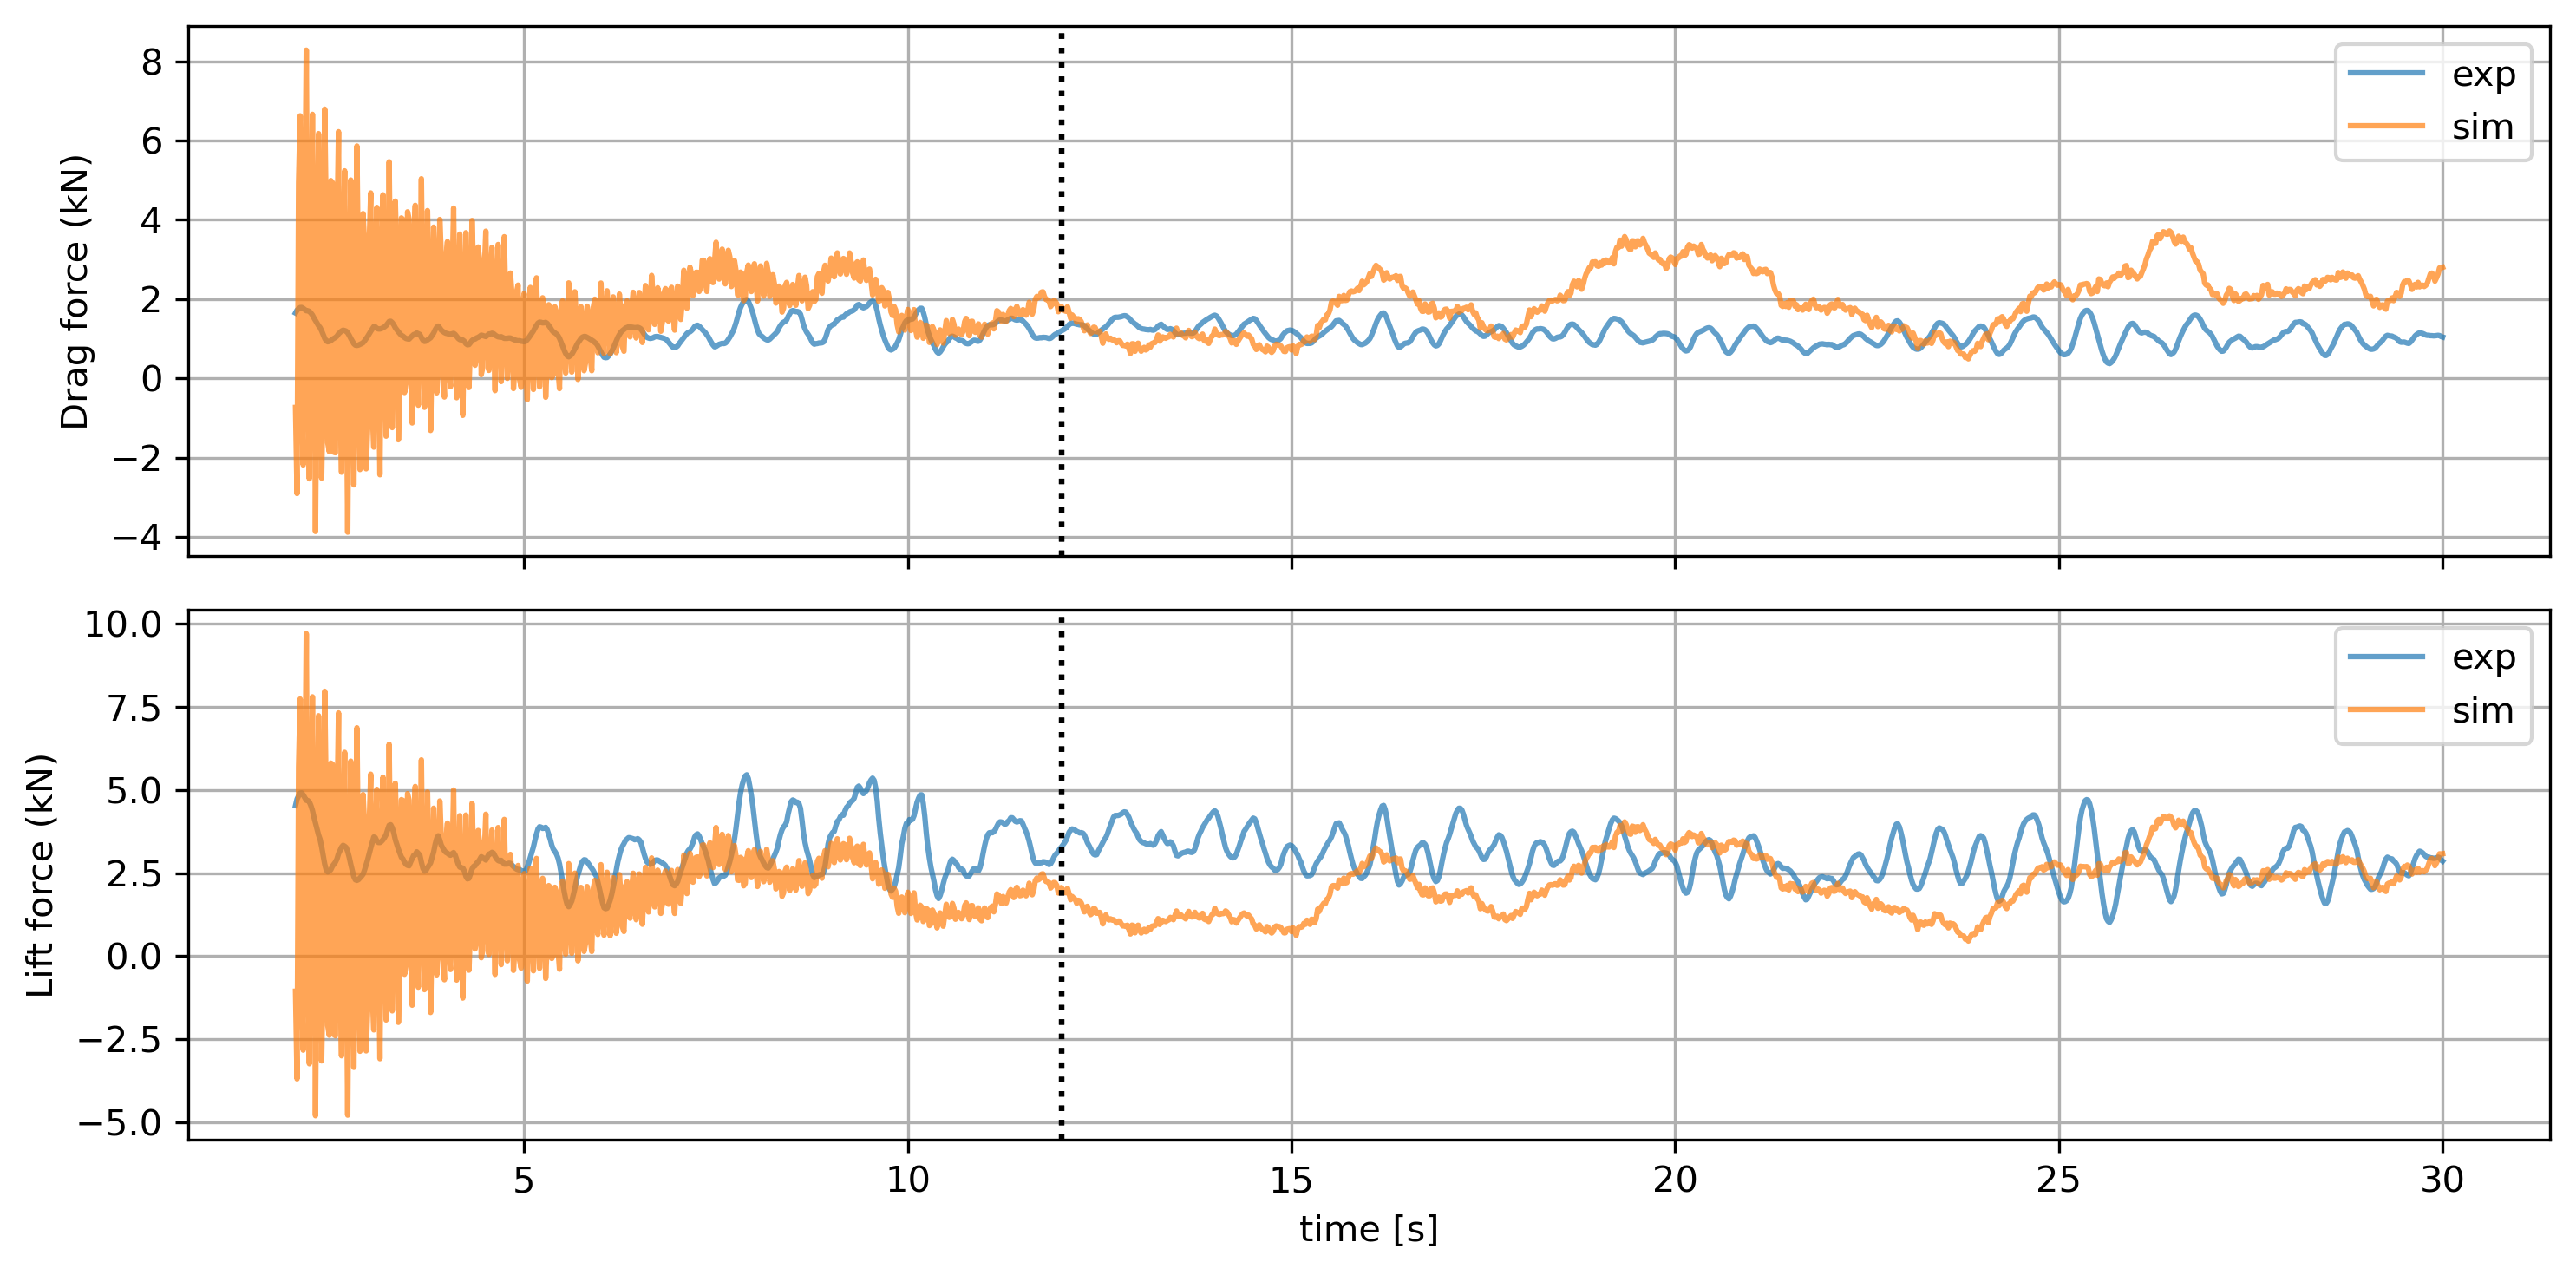

In [17]:
# first glance at all timeseries
plt.style.use('default')
time_threshold = 12.0 # s

vars = ['Drag force (kN)', 'Lift force (kN)']

fig, axs = plt.subplots(2,1,figsize=[10,5],sharex=True, dpi=300) #, sharey=True)
# plt.suptitle('u='+u+' m/s')
for n,var in enumerate(vars):
    for key in alldata.keys():
        pltdata = alldata[key][var][alldata[key][var].index > 2.0]
        axs[n].plot(pltdata, alpha=0.7, label=key)
        axs[n].axvline(time_threshold, linestyle=':', color='k')
        axs[n].set_ylabel(var)
        axs[n].legend()
        # axs[0].set_xlim([15, 20])
        # axs[0].set_ylim([0.0, 4.0])

for ax in axs:
    ax.grid()
    # ax.legend()

# for ax in axs:
axs[-1].set_xlabel('time [s]')

plt.tight_layout()

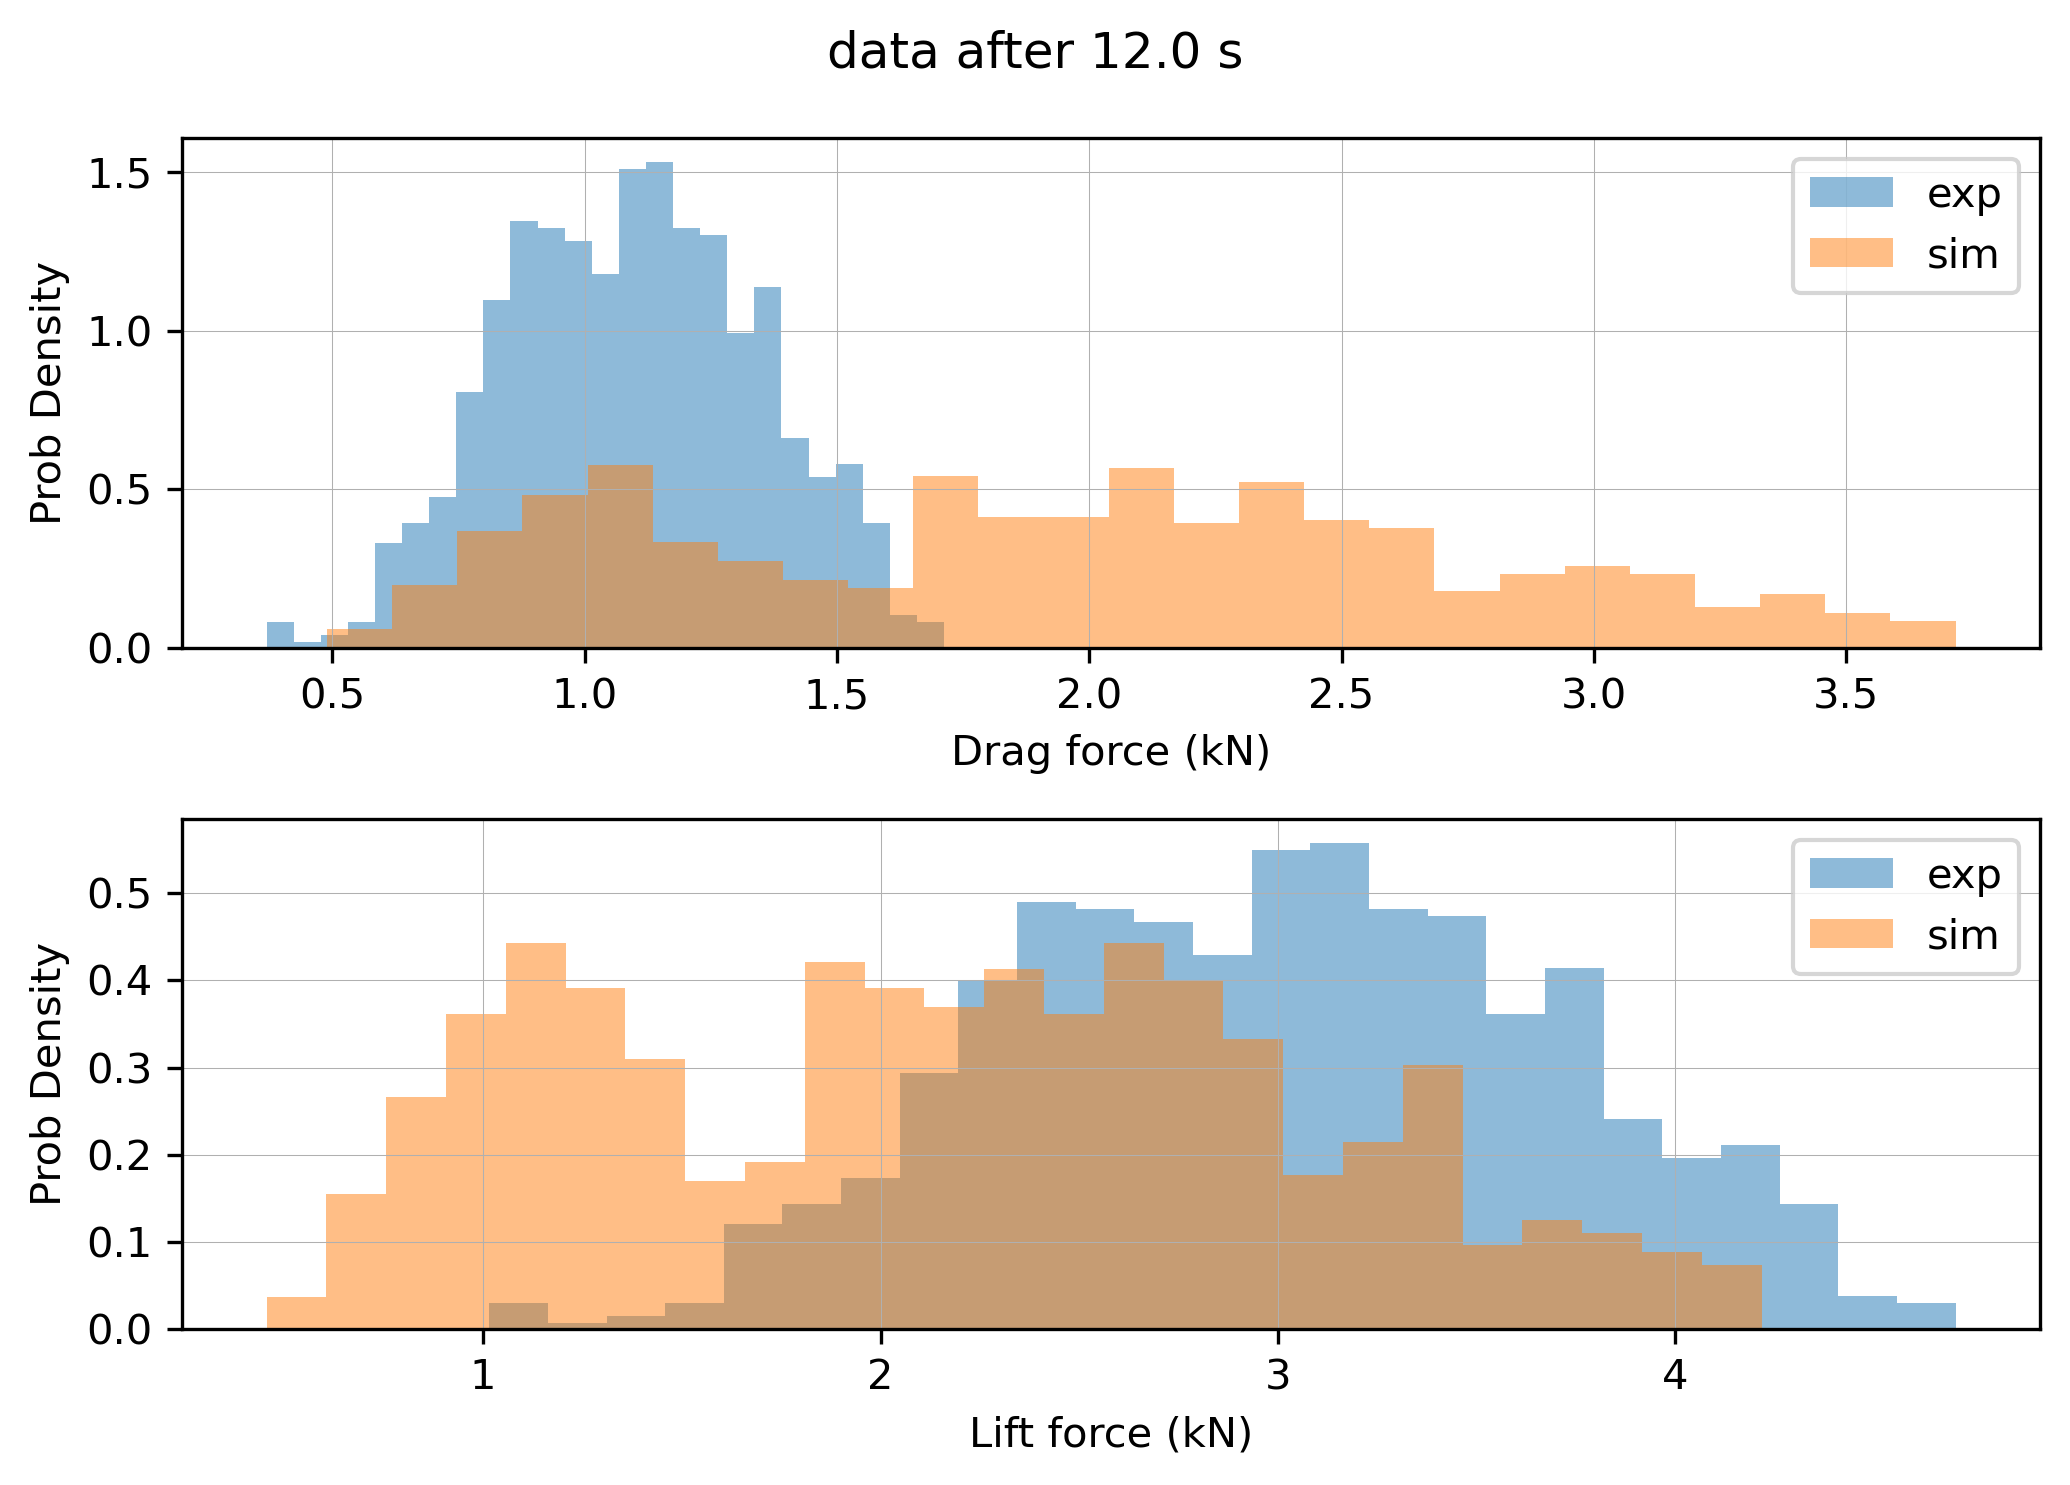

In [26]:
# histograms
plotdata = interp_sim_data[interp_sim_data.index > time_threshold]
plt_exp_data = exp_data[exp_data.index > time_threshold]

vars = ['Drag force (kN)', 'Lift force (kN)']
nbins = 25

# for k,angle in enumerate(float_list_to_str_list(tracker_angles0)):
fig, axs = plt.subplots(2,1,figsize=[7,5], dpi=300) #, sharey=True)
plt.suptitle(f'data after {time_threshold} s')
# for j,u in enumerate(float_list_to_str_list(u_refs0)):

for n,var in enumerate(vars):
    for key in alldata.keys():
        pltdata = alldata[key][var][alldata[key][var].index > time_threshold]
        axs[n].hist(pltdata, bins=nbins, density=True, alpha=0.5, label=key)
        axs[n].set_xlabel(var)
        axs[n].legend()

# axs[0].hist(plt_exp_data['Drag force tracker angle (kN)'], bins=nbins, density=True, alpha=0.5, label='experimental')
# axs[0].hist(plotdata['fx_0']/1000, bins=nbins, density=True, alpha=0.5, label='sim, interpolated')
# axs[0].set_xlabel('Drag force tracker angle (kN)')

# axs[1].hist(exp_data['Lift force tracker angle (kN)'], bins=nbins, density=True, alpha=0.5, label='experimental')
# axs[1].hist(plotdata['fz_0']/1000, bins=nbins, alpha=0.5, density=True, label='sim, interpolated')
# axs[1].set_xlabel('Lift force tracker angle (kN)')

# axs[0].set_title('u='+u+' m/s')

for ax in axs:
    ax.grid(lw=0.25)
    ax.legend()
    ax.set_ylabel('Prob Density')

# # for ax in axs:
# axs[-1].set_xlabel('time [s]')

plt.tight_layout()

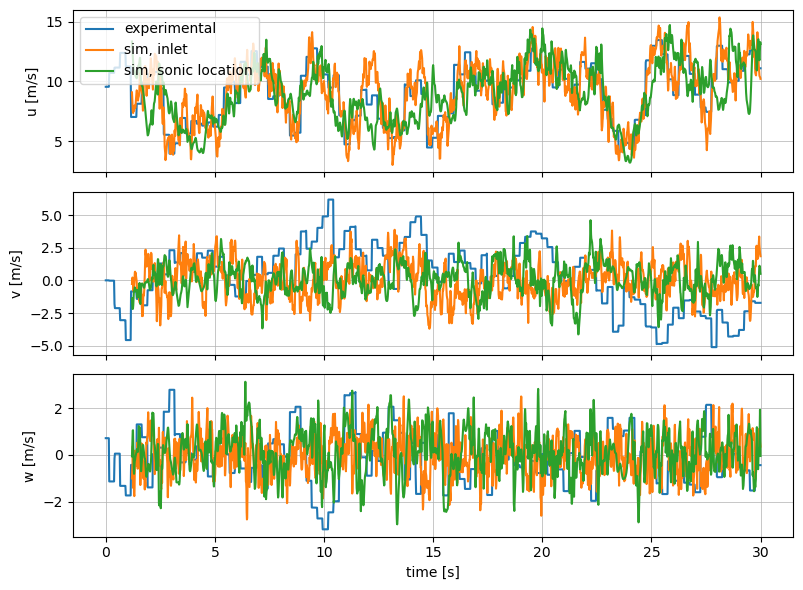

In [33]:
# plot velocity signals
fig, axs = plt.subplots(3,1, figsize=[8,6], sharex=True)

for comp,ax in zip(['u','v','w'], axs.ravel()):
    ax.plot(exp_data[comp+' (m/s)'], label='experimental')
    ax.plot(sim_data[comp+' (m/s) at inlet'], label='sim, inlet')
    ax.plot(sim_data[comp+' (m/s) at sonic'], label='sim, sonic location')
    ax.set_ylabel(f"{comp} [m/s]")
    ax.grid(lw=0.5)
axs[0].legend()
axs[-1].set_xlabel("time [s]")
plt.tight_layout()

In [ ]:
# spectra of flow

In [ ]:
# spectra of loads